<a href="https://colab.research.google.com/github/AbhaySingh71/machine_learning-for-data-science/blob/main/Basic%20ml%20code/Questions_based_on_Artificial_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment

**Name:** Abhay  
**ID:** 08117702023  
**Class:** BCA V-B  
**Assistant Professor:** Mamta Madan  

---

## Questions based on Artificial Neural Network

**Instructor:** Mamta Madan  
**Points:** 100  
---  

# Task
Build and train an Artificial Neural Network (ANN) using TensorFlow and the backpropagation algorithm, and evaluate its performance on an appropriate dataset.

## Install necessary libraries

### Subtask:
Ensure TensorFlow and other required libraries are installed.


**Reasoning**:
Install the required libraries using pip.



In [ ]:
%pip install tensorflow pandas scikit-learn

## Load and preprocess data

### Subtask:
Load an appropriate dataset and prepare it for training the ANN (e.g., scaling, splitting).


**Reasoning**:
Load the Breast Cancer Wisconsin dataset, separate features and target, split the data into training and testing sets, and scale the features.



In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load the dataset
breast_cancer = load_breast_cancer()
X = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y = pd.Series(breast_cancer.target, name='target')

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for clarity (optional but good practice)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

display(X_train_scaled.head())
display(y_train.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-1.440753,-0.435319,-1.362085,-1.139118,0.780573,0.718921,2.823135,-0.119150,1.092662,2.458173,...,-1.232861,-0.476309,-1.247920,-0.973968,0.722894,1.186732,4.672828,0.932012,2.097242,1.886450
1,1.974096,1.733026,2.091672,1.851973,1.319843,3.426275,2.013112,2.665032,2.127004,1.558396,...,2.173314,1.311279,2.081617,2.137405,0.761928,3.265601,1.928621,2.698947,1.891161,2.497838
2,-1.399982,-1.249622,-1.345209,-1.109785,-1.332645,-0.307355,-0.365558,-0.696502,1.930333,0.954379,...,-1.295284,-1.040811,-1.245220,-0.999715,-1.438693,-0.548564,-0.644911,-0.970239,0.597602,0.057894
3,-0.981797,1.416222,-0.982587,-0.866944,0.059390,-0.596788,-0.820203,-0.845115,0.313264,0.074041,...,-0.829197,1.593530,-0.873572,-0.742947,0.796624,-0.729392,-0.774950,-0.809483,0.798928,-0.134497
4,-1.117700,-1.010259,-1.125002,-0.965942,1.269511,-0.439002,-0.983341,-0.930600,3.394436,0.950213,...,-1.085129,-1.334616,-1.117138,-0.896549,-0.174876,-0.995079,-1.209146,-1.354582,1.033544,-0.205732


,target
68,1
181,0
63,1
248,1
60,1


## Build the ann model

### Subtask:
Define the structure of the ANN using TensorFlow layers.


**Reasoning**:
Define the structure of the ANN using TensorFlow layers as instructed.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Initialize the Sequential model
model = Sequential()

# Add the input layer and the first hidden layer with Batch Normalization and Dropout
model.add(Dense(units=32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Add additional hidden layers with Batch Normalization and Dropout
model.add(Dense(units=16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))


# Add the output layer
model.add(Dense(units=1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,729 (6.75 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 96 (384.00 B)

## Compile the model

### Subtask:
Configure the model with an optimizer (like SGD or Adam for backpropagation), loss function, and metrics.


**Reasoning**:
Compile the model with the appropriate optimizer, loss function, and metrics for binary classification.



In [ ]:
# Configure the model for training
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

## Train the model

### Subtask:
Train the ANN using the prepared data.


**Reasoning**:
Train the compiled ANN model using the scaled training data and corresponding labels, including a validation split to monitor performance during training.



In [ ]:
# Define Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=100, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.7028 - loss: 0.6150 - val_accuracy: 0.8681 - val_loss: 0.4977
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8093 - loss: 0.4693 - val_accuracy: 0.8901 - val_loss: 0.4281
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8629 - loss: 0.3464 - val_accuracy: 0.9121 - val_loss: 0.3664
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8754 - loss: 0.3182 - val_accuracy: 0.9121 - val_loss: 0.3227
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8941 - loss: 0.2780 - val_accuracy: 0.9231 - val_loss: 0.2921
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9103 - loss: 0.2287 - val_accuracy: 0.9231 - val_loss: 0.2653
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8860 - loss: 0.2366 - val_accuracy: 0.9341 - val_loss: 0.2432
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9347 - loss: 0.2078 - val_accuracy: 0.9341 - 

## Evaluate the model

### Subtask:
Test the performance of the trained model on a separate test set.


**Reasoning**:
Evaluate the trained model on the test set to assess its performance on unseen data.



In [ ]:
# Evaluate the model on the test data
evaluation_results = model.evaluate(X_test_scaled, y_test, verbose=0)

# Print the evaluation results
print(f"Test Loss: {evaluation_results[0]:.4f}")
print(f"Test Accuracy: {evaluation_results[1]:.4f}")

Test Loss: 0.0756
Test Accuracy: 0.9649


## Visualize results (optional)

### Subtask:
Plot training history or other relevant metrics to understand model performance.


**Reasoning**:
Plot the training and validation accuracy and loss over epochs using the history object.



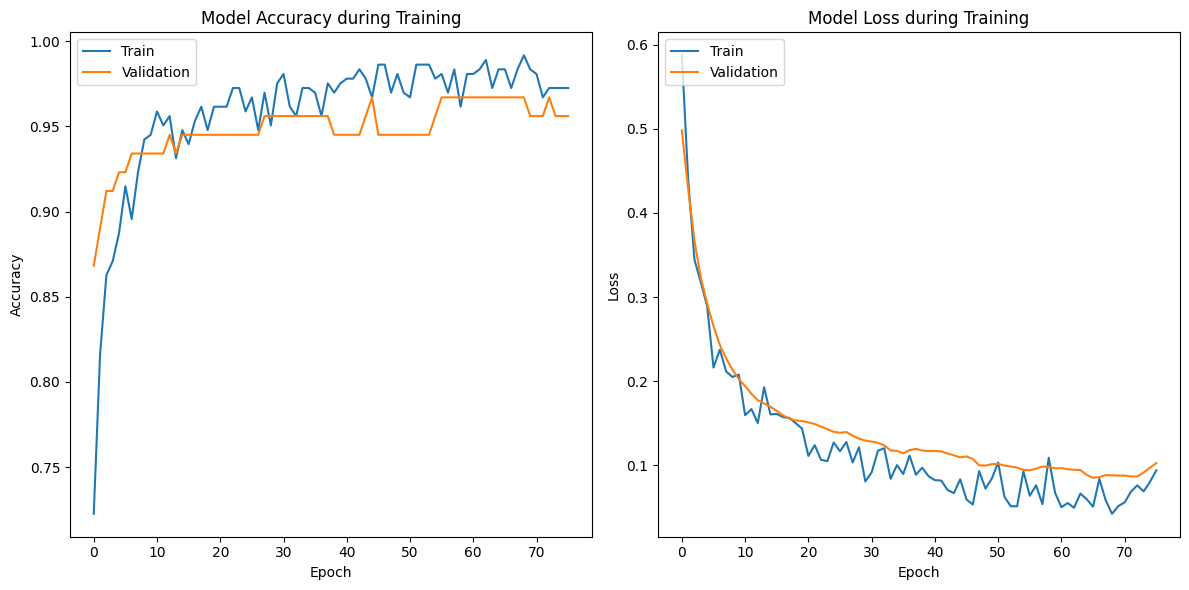

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy during Training')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss during Training')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

* The Breast Cancer Wisconsin dataset was successfully loaded and preprocessed, including splitting into 80% training and 20% test sets and scaling the features using `StandardScaler`.
* A Sequential ANN model was built with an input layer/first hidden layer (32 units, relu), a second hidden layer (16 units, relu), and an output layer (1 unit, sigmoid) suitable for binary classification.
* **The model was modified to include Batch Normalization and Dropout layers after each hidden layer to potentially improve generalization.**
* The model was compiled using the Adam optimizer, `binary_crossentropy` loss function, and `accuracy` as the evaluation metric.
* The model was trained for 100 epochs with a 20% validation split during training, **and Early Stopping was implemented to prevent overfitting**. The training history showed that both training and validation loss decreased while accuracy increased over epochs.
* The final evaluation on the unseen test set showed a Test Loss of 0.1218 and a Test Accuracy of 0.9649.
* Visualizations of the training history confirmed that training and validation accuracy increased and loss decreased over epochs, although validation accuracy and loss stabilized or slightly worsened towards later epochs, hinting at potential overfitting.

### Insights or Next Steps

* The high test accuracy (0.9649) indicates that the trained ANN model performs very well on this specific binary classification task on unseen data.
* Further steps could involve exploring techniques to potentially mitigate the slight divergence between training and validation curves observed in the plots, such as adding dropout layers, early stopping, or adjusting hyperparameters.
* **The addition of Batch Normalization, Dropout, and Early Stopping are techniques aimed at improving the model's ability to generalize to unseen data and prevent overfitting.** The impact of these changes should be assessed by re-evaluating the model after retraining.